# Exploratory Data Analysis — *Default of Credit Card Clients*

**Tujuan notebook ini:** memahami karakteristik dataset **sebelum** masuk ke tahap *preprocessing* & *modeling*, sehingga setiap keputusan pembersihan data nanti punya **dasar bukti** (bukan asumsi).

Dataset: **30.000** pemegang kartu kredit di Taiwan (Apr–Sep 2005). Target: apakah klien **gagal bayar** pada bulan berikutnya (`default payment next month`: `0` = lancar, `1` = gagal bayar).

## 1. Setup & Load Data

In [1]:
# Instalasi (uncomment bila belum terpasang)
# !pip install pandas numpy matplotlib seaborn xlrd

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# --- Tema visual konsisten untuk seluruh notebook ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]        = 110
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.titlesize"]    = 12
plt.rcParams["font.size"]         = 10

# Palet warna SEMANTIK untuk target (dipakai konsisten di mana pun)
C_LANCAR = "#2A9D8F"   # 0 = lancar  (hijau-teal)
C_GAGAL  = "#E76F51"   # 1 = gagal bayar (merah-koral)
ACCENT   = "#4C72B0"   # warna netral untuk plot non-target
TARGET_PALETTE = {0: C_LANCAR, 1: C_GAGAL}
TARGET_LABELS  = {0: "Lancar (0)", 1: "Gagal Bayar (1)"}

print("Library & tema visual siap.")

Library & tema visual siap.


In [3]:
# === Lokasi file — UBAH sesuai tempat Anda menyimpannya ===
# Contoh Google Colab + Drive:
# DATA_PATH = "/content/drive/MyDrive/DATASET/Module_ML_GDGOC_EDA/defaultCreditCardClients.xls"
DATA_PATH = "defaultCreditCardClients.xls"

# header=1  -> ambil nama kolom dari baris ke-2 (lihat catatan di atas)
df = pd.read_excel(DATA_PATH, engine="xlrd", header=1)

TARGET = "default payment next month"   # nama kolom target (dipakai berulang)

print(f"Dataset dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Dataset dimuat: 30,000 baris x 25 kolom


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Sekilas Data

In [4]:
# Tipe data & memori
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
# Statistik deskriptif (ditranspos agar mudah dibaca per fitur)
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.50,8660.40,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0


**Pengamatan awal dari statistik deskriptif:**
- Semua kolom bertipe `int64` — termasuk variabel yang sebenarnya **kategorikal** (`SEX`, `EDUCATION`, `MARRIAGE`, `PAY_*`). Ini hanya *encoding* angka, bukan besaran numerik sungguhan → perlu diperlakukan khusus saat *encoding*.
- Kolom uang (`LIMIT_BAL`, `BILL_AMT*`, `PAY_AMT*`) punya jarak **min–max sangat lebar** dan `mean` ≫ `median` → indikasi awal **distribusi menceng kanan** (akan kita konfirmasi).
- `BILL_AMT*` punya nilai **minimum negatif** → kemungkinan kelebihan bayar / saldo kredit, bukan error.

## 3. Kamus Data

Memahami arti variabel itu krusial untuk dataset finansial — banyak kolom berisi **kode**, bukan nilai literal.

| Kolom | Arti | Keterangan nilai |
|---|---|---|
| `ID` | Nomor identitas klien | Sekadar identifier (bukan prediktor) |
| `LIMIT_BAL` | Batas kredit (NT$) | Termasuk kredit individu + keluarga |
| `SEX` | Jenis kelamin | 1 = pria, 2 = wanita |
| `EDUCATION` | Pendidikan | 1 = S2/S3, 2 = universitas, 3 = SMA, 4 = lainnya |
| `MARRIAGE` | Status pernikahan | 1 = menikah, 2 = lajang, 3 = lainnya |
| `AGE` | Umur (tahun) | — |
| `PAY_0`–`PAY_6` | Status pembayaran Sep→Apr 2005 | −1 = bayar tepat waktu; 1..9 = telat 1..9 bulan |
| `BILL_AMT1`–`6` | Jumlah tagihan Sep→Apr 2005 (NT$) | — |
| `PAY_AMT1`–`6` | Jumlah pembayaran Sep→Apr 2005 (NT$) | — |
| `default payment next month` | **TARGET** | 0 = lancar, 1 = gagal bayar |

> **Catatan penamaan:** kolom status pembayaran melompat dari `PAY_0` langsung ke `PAY_2` (tidak ada `PAY_1`). `PAY_0` sebenarnya status bulan **terbaru** (September). Pada preprocessing biasanya `PAY_0` diganti nama menjadi `PAY_1` agar konsisten.

## 4. Audit Kualitas Data

Tiga pemeriksaan: **missing values**, **duplikat**, dan **konsistensi kategori terhadap dokumentasi**.

### 4.1 Missing values

In [6]:
missing = df.isna().sum()
print("Total missing values di seluruh dataset:", int(missing.sum()))
print("\nKolom dengan missing (jika ada):")
print(missing[missing > 0] if missing.sum() > 0 else "  (tidak ada missing value eksplisit)")

Total missing values di seluruh dataset: 0

Kolom dengan missing (jika ada):
  (tidak ada missing value eksplisit)


**Insight:** Tidak ada `NaN` eksplisit. Namun "bersih" di sini **menyesatkan** — masalah sesungguhnya tersembunyi sebagai **kategori tak terdokumentasi** (lihat 4.3), yang secara teknis terbaca sebagai angka valid padahal maknanya tidak terdefinisi.

### 4.2 Duplikat

In [7]:
dup_full  = df.duplicated().sum()
feature_cols = [c for c in df.columns if c != "ID"]
dup_no_id = df[feature_cols].duplicated().sum()

print(f"Duplikat baris penuh (termasuk ID) : {dup_full}")
print(f"Duplikat baris TANPA kolom ID      : {dup_no_id}")

Duplikat baris penuh (termasuk ID) : 0
Duplikat baris TANPA kolom ID      : 35


**Insight:** Karena `ID` unik untuk tiap baris, secara naif "tidak ada duplikat". Tetapi setelah `ID` diabaikan, ada **35 klien dengan profil identik**. Inilah duplikat yang relevan — bila dibiarkan, model bisa **bias** dan performanya **terlampau optimis**. → kandidat dihapus saat preprocessing.

### 4.3 Konsistensi kategori terhadap dokumentasi  *(temuan kunci)*

In [8]:
allowed = {
    "SEX":       {1, 2},
    "EDUCATION": {1, 2, 3, 4},
    "MARRIAGE":  {1, 2, 3},
}

for col, ok in allowed.items():
    vc = df[col].value_counts().sort_index()
    outside = sorted(set(vc.index) - ok)
    print(f"{col:10s} | nilai: {vc.to_dict()}")
    print(f"{'':10s} | DI LUAR dokumentasi -> {outside}\n")

# Audit status pembayaran PAY_* (dokumentasi: -1, 1..9)
pay_cols    = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
allowed_pay = set([-1] + list(range(1, 10)))
print("Audit PAY_* (di luar dokumentasi {-1, 1..9}):")
for c in pay_cols:
    outside = sorted(set(df[c].unique()) - allowed_pay)
    print(f"  {c:6s} -> {outside}")

SEX        | nilai: {1: 11888, 2: 18112}
           | DI LUAR dokumentasi -> []

EDUCATION  | nilai: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
           | DI LUAR dokumentasi -> [0, 5, 6]

MARRIAGE   | nilai: {0: 54, 1: 13659, 2: 15964, 3: 323}
           | DI LUAR dokumentasi -> [0]

Audit PAY_* (di luar dokumentasi {-1, 1..9}):
  PAY_0  -> [np.int64(-2), np.int64(0)]
  PAY_2  -> [np.int64(-2), np.int64(0)]
  PAY_3  -> [np.int64(-2), np.int64(0)]
  PAY_4  -> [np.int64(-2), np.int64(0)]
  PAY_5  -> [np.int64(-2), np.int64(0)]
  PAY_6  -> [np.int64(-2), np.int64(0)]


In [9]:
# Seberapa besar porsi anomali pada EDUCATION & MARRIAGE?
edu_anom = df["EDUCATION"].isin([0, 5, 6]).sum()
mar_anom = df["MARRIAGE"].isin([0]).sum()
print(f"EDUCATION di luar dokumentasi (0/5/6): {edu_anom} baris  ({edu_anom/len(df)*100:.2f}%)")
print(f"MARRIAGE  di luar dokumentasi (0)    : {mar_anom} baris  ({mar_anom/len(df)*100:.2f}%)")

EDUCATION di luar dokumentasi (0/5/6): 345 baris  (1.15%)
MARRIAGE  di luar dokumentasi (0)    : 54 baris  (0.18%)


**Insight (penting):**
- `EDUCATION` memuat kode **0, 5, 6** dan `MARRIAGE` memuat **0** — semuanya **tidak ada di dokumentasi**. Porsinya kecil (EDUCATION ≈ 1,15%, MARRIAGE ≈ 0,18%), sehingga aman untuk diperlakukan sebagai **nilai tak terdefinisi** (tandai `NaN` lalu imputasi) ketimbang dibuang.
- `PAY_*` memuat **−2** dan **0** yang juga di luar dokumentasi. Tafsir lazim: `−2` = tidak ada tagihan/penggunaan, `0` = membayar minimum (revolving credit). Karena bermakna, nilai ini umumnya **dipertahankan**, bukan dibuang.

Temuan inilah dasar langkah *handling missing / inkonsistensi* di preprocessing.

## 5. Analisis Target — *Class Imbalance*

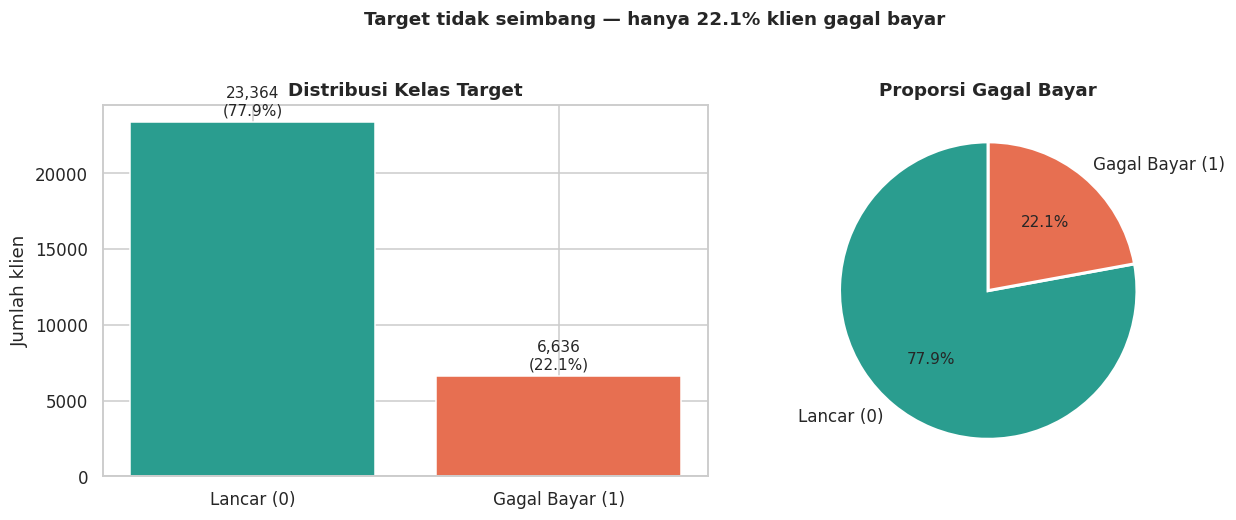

Rasio kelas ~ 3.52 : 1  (sekitar 3.5 klien lancar untuk tiap 1 klien gagal bayar)


In [10]:
counts = df[TARGET].value_counts().sort_index()
rate   = df[TARGET].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar
labels = [TARGET_LABELS[i] for i in counts.index]
bars = axes[0].bar(labels, counts.values,
                   color=[TARGET_PALETTE[i] for i in counts.index], edgecolor="white")
axes[0].set_title("Distribusi Kelas Target")
axes[0].set_ylabel("Jumlah klien")
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 250,
                 f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha="center", va="bottom")

# Pie
axes[1].pie(counts.values, labels=labels,
            colors=[TARGET_PALETTE[i] for i in counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporsi Gagal Bayar")

plt.suptitle(f"Target tidak seimbang — hanya {rate:.1f}% klien gagal bayar",
             y=1.04, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Rasio kelas ~ {counts[0]/counts[1]:.2f} : 1  "
      f"(sekitar {counts[0]/counts[1]:.1f} klien lancar untuk tiap 1 klien gagal bayar)")

**Insight:** Hanya **22,1%** klien yang gagal bayar — dataset **tidak seimbang**. Konsekuensinya:
- **Akurasi menyesatkan**: menebak "semua lancar" saja sudah ~78% akurat. → fokus evaluasi pada **AUC, recall, F1**, bukan akurasi.
- Saat training perlu **imbalance handling** (mis. *class weight* / *resampling* seperti SMOTE).

## 6. Analisis Univariat — Fitur Numerik

### 6.1 LIMIT_BAL & AGE

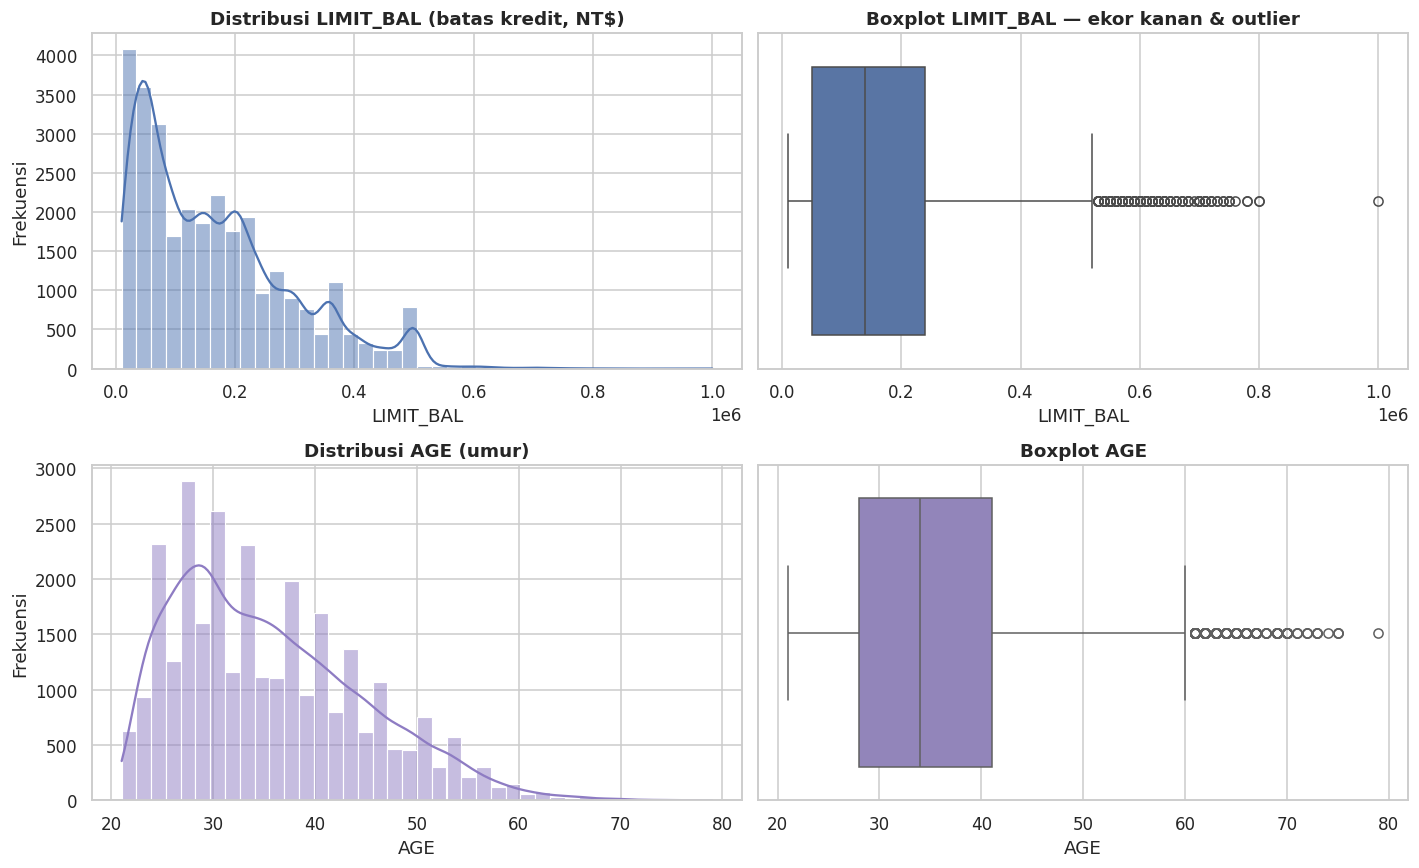

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["LIMIT_BAL"], bins=40, kde=True, color=ACCENT, ax=axes[0, 0])
axes[0, 0].set_title("Distribusi LIMIT_BAL (batas kredit, NT$)")
axes[0, 0].set_xlabel("LIMIT_BAL"); axes[0, 0].set_ylabel("Frekuensi")

sns.boxplot(x=df["LIMIT_BAL"], color=ACCENT, ax=axes[0, 1])
axes[0, 1].set_title("Boxplot LIMIT_BAL — ekor kanan & outlier")
axes[0, 1].set_xlabel("LIMIT_BAL")

sns.histplot(df["AGE"], bins=40, kde=True, color="#8E7CC3", ax=axes[1, 0])
axes[1, 0].set_title("Distribusi AGE (umur)")
axes[1, 0].set_xlabel("AGE"); axes[1, 0].set_ylabel("Frekuensi")

sns.boxplot(x=df["AGE"], color="#8E7CC3", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot AGE")
axes[1, 1].set_xlabel("AGE")

plt.tight_layout(); plt.show()

**Insight:** `LIMIT_BAL` **menceng kanan** — mayoritas klien berlimit rendah-menengah, segelintir berlimit sangat tinggi (hingga 1 juta NT$). `AGE` terkonsentrasi di **20–40 tahun** dengan ekor ke usia tua. Keduanya punya outlier → relevan untuk *outlier handling* nanti.

### 6.2 BILL_AMT & PAY_AMT (kolom uang berkala)

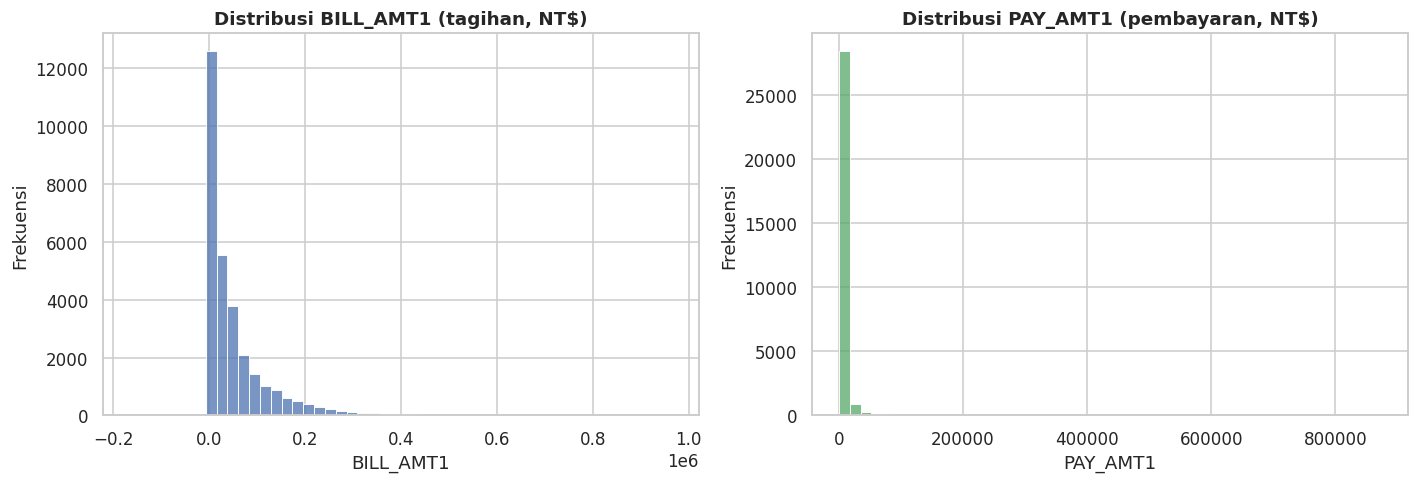

Klien dengan minimal satu BILL_AMT negatif (kelebihan bayar): 1,930


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["BILL_AMT1"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribusi BILL_AMT1 (tagihan, NT$)")
axes[0].set_xlabel("BILL_AMT1"); axes[0].set_ylabel("Frekuensi")

sns.histplot(df["PAY_AMT1"], bins=50, color="#55A868", ax=axes[1])
axes[1].set_title("Distribusi PAY_AMT1 (pembayaran, NT$)")
axes[1].set_xlabel("PAY_AMT1"); axes[1].set_ylabel("Frekuensi")

plt.tight_layout(); plt.show()

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
neg_clients = (df[bill_cols] < 0).any(axis=1).sum()
print(f"Klien dengan minimal satu BILL_AMT negatif (kelebihan bayar): {neg_clients:,}")

### 6.3 Ringkasan *skewness* seluruh kolom uang

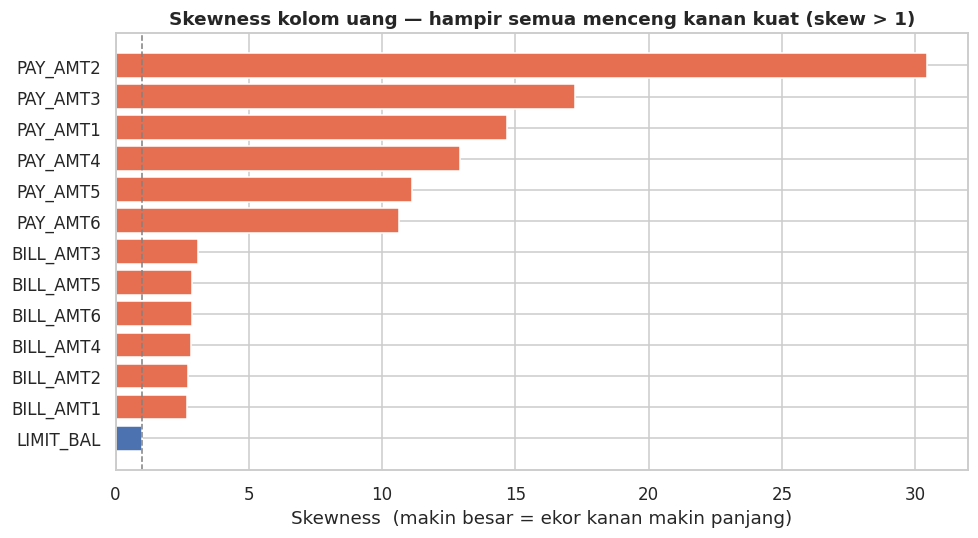

In [13]:
money_cols = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
skew = df[money_cols].skew().sort_values()

plt.figure(figsize=(9, 5))
colors = [C_GAGAL if s > 1 else ACCENT for s in skew.values]
plt.barh(skew.index, skew.values, color=colors, edgecolor="white")
plt.axvline(1, color="gray", ls="--", lw=1)
plt.title("Skewness kolom uang — hampir semua menceng kanan kuat (skew > 1)")
plt.xlabel("Skewness  (makin besar = ekor kanan makin panjang)")
plt.tight_layout(); plt.show()

**Insight:** Hampir semua kolom uang **sangat menceng kanan** (skew jauh > 1; `PAY_AMT` ekstrem hingga ~30 karena segelintir pembayaran sangat besar). Nilai negatif `BILL_AMT` = kelebihan bayar (bukan error). Implikasi: model linier/berbasis jarak akan terganggu skala & ekor ini → butuh **outlier capping** + **scaling**.

## 7. Analisis Univariat — Fitur Kategorikal

Batang **merah** menandai kategori **di luar dokumentasi** (temuan dari audit 4.3).

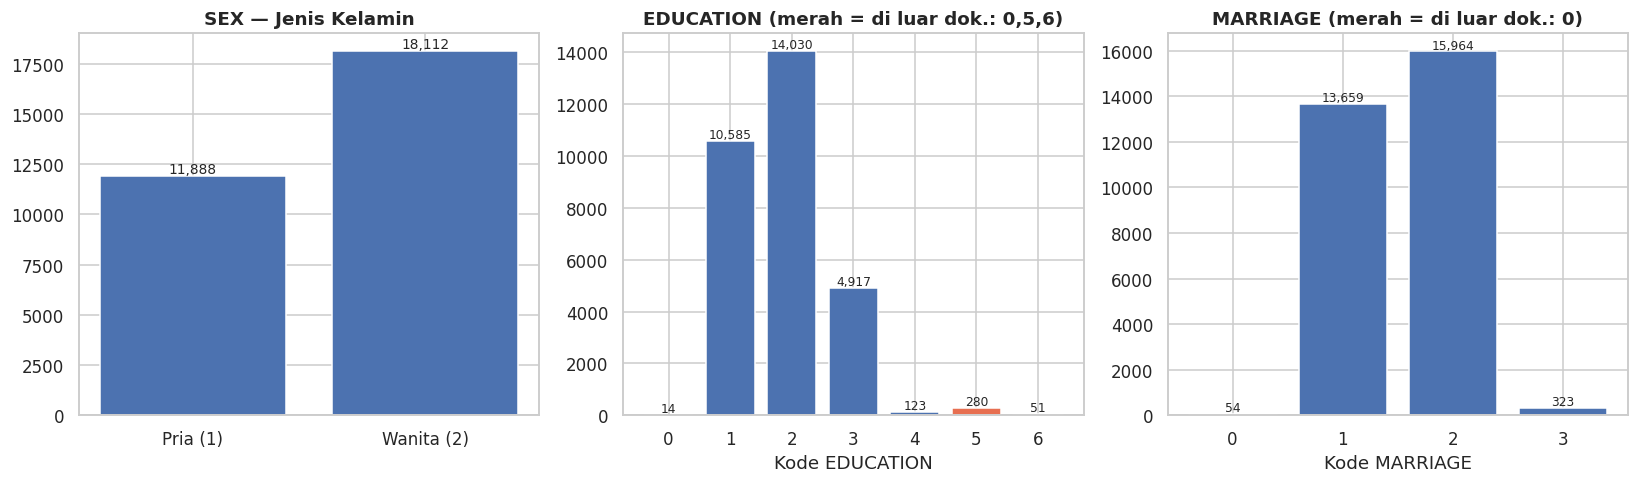

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# SEX
sex_map = {1: "Pria (1)", 2: "Wanita (2)"}
vc = df["SEX"].value_counts().sort_index()
axes[0].bar([sex_map[i] for i in vc.index], vc.values, color=ACCENT, edgecolor="white")
axes[0].set_title("SEX — Jenis Kelamin")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 150, f"{v:,}", ha="center", fontsize=9)

# EDUCATION (sorot 0,5,6)
vc = df["EDUCATION"].value_counts().sort_index()
edu_colors = [ACCENT if i in {1, 2, 3, 4} else C_GAGAL for i in vc.index]
axes[1].bar([str(i) for i in vc.index], vc.values, color=edu_colors, edgecolor="white")
axes[1].set_title("EDUCATION (merah = di luar dok.: 0,5,6)")
axes[1].set_xlabel("Kode EDUCATION")
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 120, f"{v:,}", ha="center", fontsize=8)

# MARRIAGE (sorot 0)
vc = df["MARRIAGE"].value_counts().sort_index()
mar_colors = [ACCENT if i in {1, 2, 3} else C_GAGAL for i in vc.index]
axes[2].bar([str(i) for i in vc.index], vc.values, color=mar_colors, edgecolor="white")
axes[2].set_title("MARRIAGE (merah = di luar dok.: 0)")
axes[2].set_xlabel("Kode MARRIAGE")
for i, v in enumerate(vc.values):
    axes[2].text(i, v + 120, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout(); plt.show()

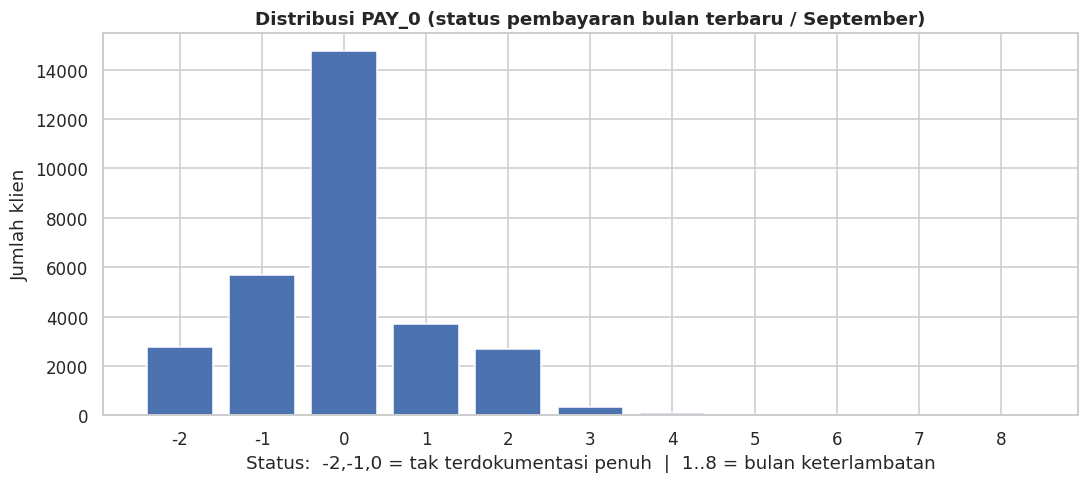

In [15]:
plt.figure(figsize=(10, 4.5))
vc = df["PAY_0"].value_counts().sort_index()
plt.bar(vc.index.astype(str), vc.values, color=ACCENT, edgecolor="white")
plt.title("Distribusi PAY_0 (status pembayaran bulan terbaru / September)")
plt.xlabel("Status:  -2,-1,0 = tak terdokumentasi penuh  |  1..8 = bulan keterlambatan")
plt.ylabel("Jumlah klien")
plt.tight_layout(); plt.show()

**Insight:** Klien didominasi **wanita** (≈60%) dan jenjang **universitas/SMA**. Pada `PAY_0`, mayoritas klien berada di status `−1/0` (tepat waktu atau revolving), dan jumlah klien **menurun tajam** seiring keterlambatan makin lama — sangat sedikit klien telat ≥ 3 bulan.

## 8. Analisis Bivariat — Hubungan Fitur ↔ Target

### 8.1 Fitur numerik per status default

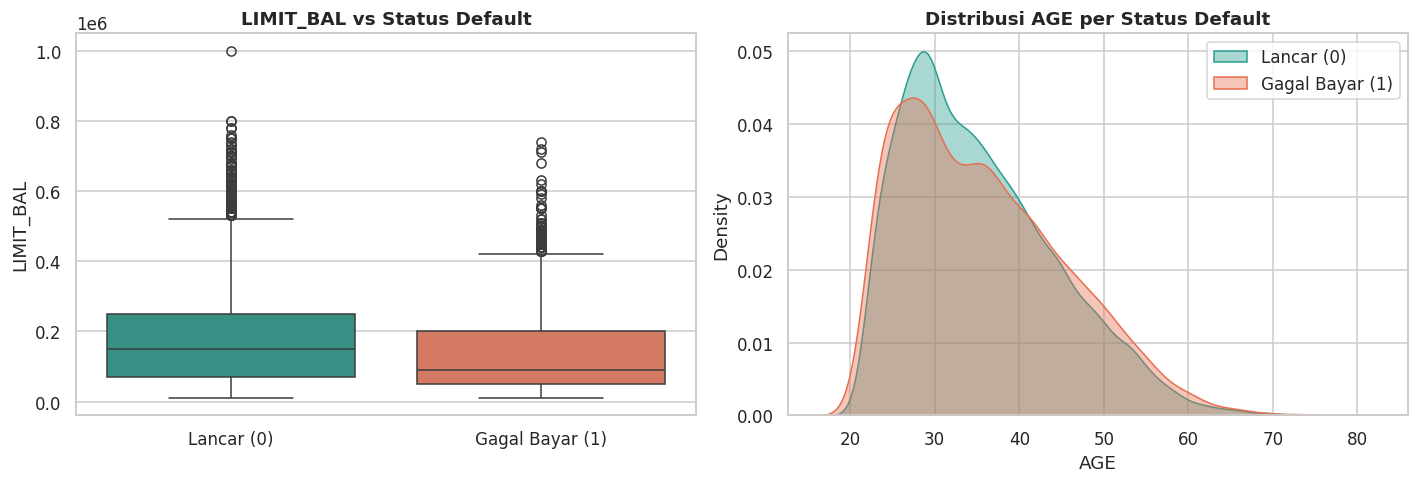

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x=TARGET, y="LIMIT_BAL", hue=TARGET,
            palette=TARGET_PALETTE, legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])
axes[0].set_title("LIMIT_BAL vs Status Default")
axes[0].set_xlabel(""); axes[0].set_ylabel("LIMIT_BAL")

for t in [0, 1]:
    sns.kdeplot(df.loc[df[TARGET] == t, "AGE"], fill=True, alpha=0.4,
                color=TARGET_PALETTE[t], label=TARGET_LABELS[t], ax=axes[1])
axes[1].set_title("Distribusi AGE per Status Default")
axes[1].set_xlabel("AGE"); axes[1].legend()

plt.tight_layout(); plt.show()

**Insight:** Klien yang **gagal bayar cenderung punya `LIMIT_BAL` lebih rendah** — limit kredit kecil sering menandakan profil risiko lebih tinggi di mata bank. Distribusi `AGE` kedua kelas mirip → umur **bukan** pembeda kuat secara mandiri.

### 8.2 Tingkat gagal bayar per kategori

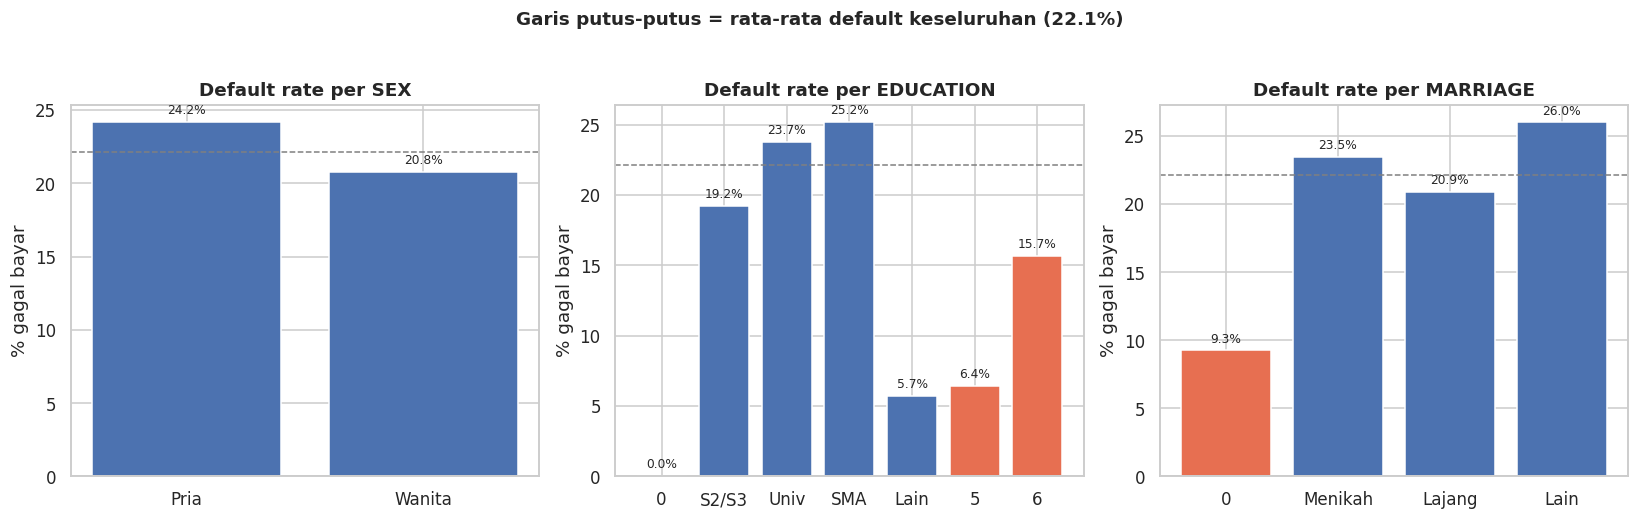

In [17]:
overall = df[TARGET].mean()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def rate_bar(ax, col, labelmap, title, doc_set=None):
    g = df.groupby(col)[TARGET].mean().sort_index()
    bar_colors = [(C_GAGAL if (doc_set is not None and idx not in doc_set) else ACCENT)
                  for idx in g.index]
    labels = [labelmap.get(idx, str(idx)) for idx in g.index]
    ax.bar(labels, g.values * 100, color=bar_colors, edgecolor="white")
    ax.axhline(overall * 100, color="gray", ls="--", lw=1)
    ax.set_title(title); ax.set_ylabel("% gagal bayar")
    for i, v in enumerate(g.values):
        ax.text(i, v * 100 + 0.6, f"{v*100:.1f}%", ha="center", fontsize=8)

rate_bar(axes[0], "SEX", {1: "Pria", 2: "Wanita"}, "Default rate per SEX")
rate_bar(axes[1], "EDUCATION", {1: "S2/S3", 2: "Univ", 3: "SMA", 4: "Lain"},
         "Default rate per EDUCATION", doc_set={1, 2, 3, 4})
rate_bar(axes[2], "MARRIAGE", {1: "Menikah", 2: "Lajang", 3: "Lain"},
         "Default rate per MARRIAGE", doc_set={1, 2, 3})

plt.suptitle(f"Garis putus-putus = rata-rata default keseluruhan ({overall*100:.1f}%)",
             y=1.04, fontweight="bold")
plt.tight_layout(); plt.show()

**Insight:** **Pria** sedikit lebih sering gagal bayar dibanding wanita. `EDUCATION` menunjukkan tren jelas: **makin rendah jenjang, makin tinggi risiko** (S2/S3 19% → SMA 25%). `MARRIAGE` perbedaannya tipis. Catatan: kategori tak terdokumentasi (batang merah) sampel-nya kecil sehingga estimasinya **kurang stabil**.

### 8.3 PAY_0 vs default — sinyal risiko terkuat

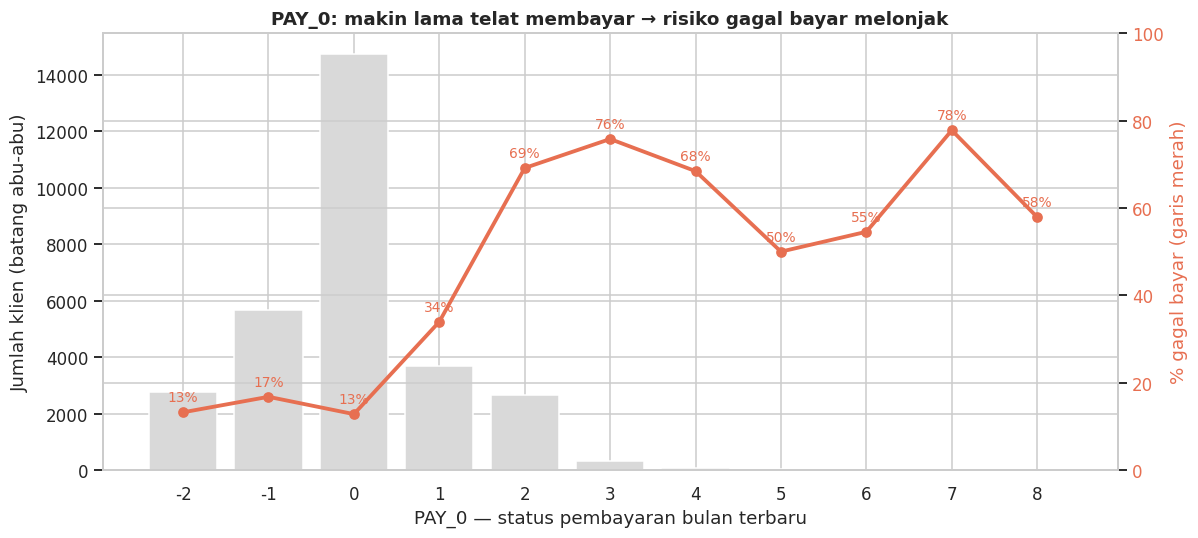

In [18]:
g = df.groupby("PAY_0")[TARGET].agg(["mean", "count"])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(g.index.astype(str), g["count"], color="#D9D9D9", edgecolor="white")
ax1.set_ylabel("Jumlah klien (batang abu-abu)")
ax1.set_xlabel("PAY_0 — status pembayaran bulan terbaru")

ax2 = ax1.twinx()
ax2.plot(range(len(g)), g["mean"] * 100, color=C_GAGAL, marker="o", lw=2.5)
ax2.set_ylabel("% gagal bayar (garis merah)", color=C_GAGAL)
ax2.tick_params(axis="y", labelcolor=C_GAGAL)
ax2.set_ylim(0, 100)
for i, v in enumerate(g["mean"] * 100):
    ax2.text(i, v + 2.5, f"{v:.0f}%", ha="center", color=C_GAGAL, fontsize=9)

plt.title("PAY_0: makin lama telat membayar → risiko gagal bayar melonjak")
plt.tight_layout(); plt.show()

**Insight (headline):** Hubungan `PAY_0` ↔ default sangat kuat dan **monoton**. Klien tepat waktu (`-1/0`) hanya ~13% gagal bayar, tetapi yang telat 2 bulan (`PAY_0 = 2`) melonjak ke **~69%**. Status pembayaran terbaru adalah **prediktor paling informatif** dalam dataset ini — sesuatu yang wajib dipertahankan & ditonjolkan saat *feature selection*.

## 9. Analisis Multivariat — Korelasi & Multikolinearitas

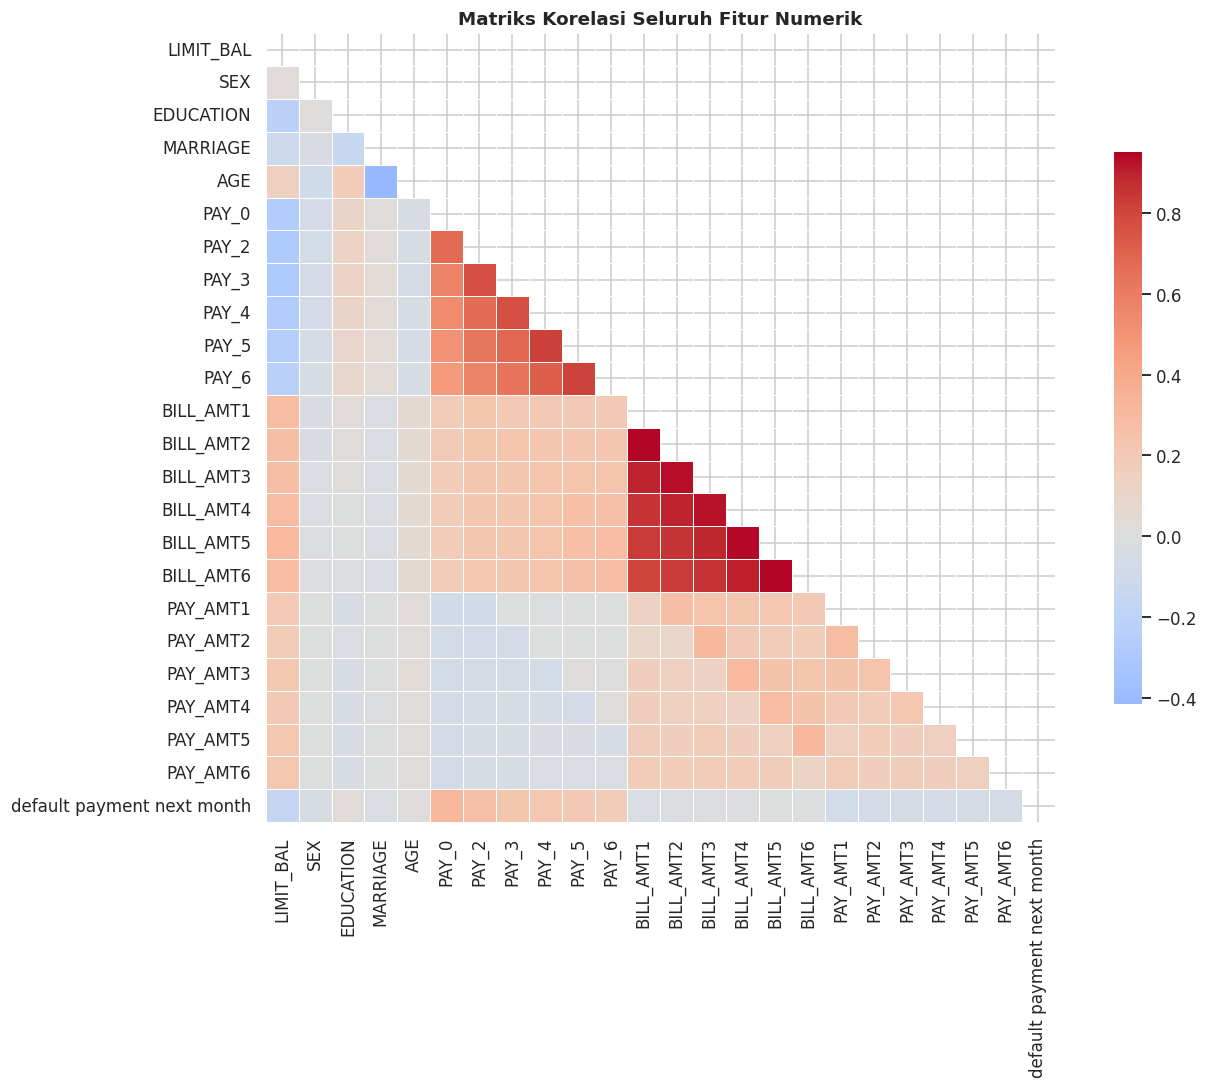

In [19]:
corr = df.drop(columns=["ID"]).corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("Matriks Korelasi Seluruh Fitur Numerik")
plt.tight_layout(); plt.show()

### 9.1 Zoom: multikolinearitas antar BILL_AMT

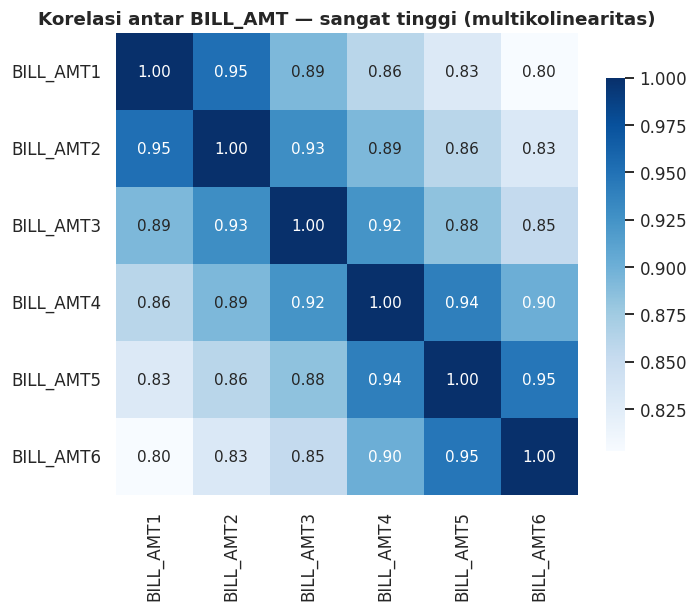

Rata-rata korelasi antar BILL_AMT: 0.886


In [20]:
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(df[bill].corr(), annot=True, fmt=".2f", cmap="Blues", square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Korelasi antar BILL_AMT — sangat tinggi (multikolinearitas)")
plt.tight_layout(); plt.show()

avg_bill_corr = df[bill].corr().values[np.triu_indices(6, 1)].mean()
print(f"Rata-rata korelasi antar BILL_AMT: {avg_bill_corr:.3f}")

**Insight:** Enam kolom `BILL_AMT` saling **berkorelasi sangat tinggi** (rata-rata ≈ 0,89) — wajar karena tagihan antar bulan berurutan mirip. Ini **multikolinearitas** yang menambah redundansi. Dasar untuk: **feature extraction** (meringkas 6 bulan jadi sinyal seperti rata-rata utilisasi / tren) dan pembuangan fitur sangat berkorelasi saat seleksi.

### 9.2 Korelasi setiap fitur terhadap target

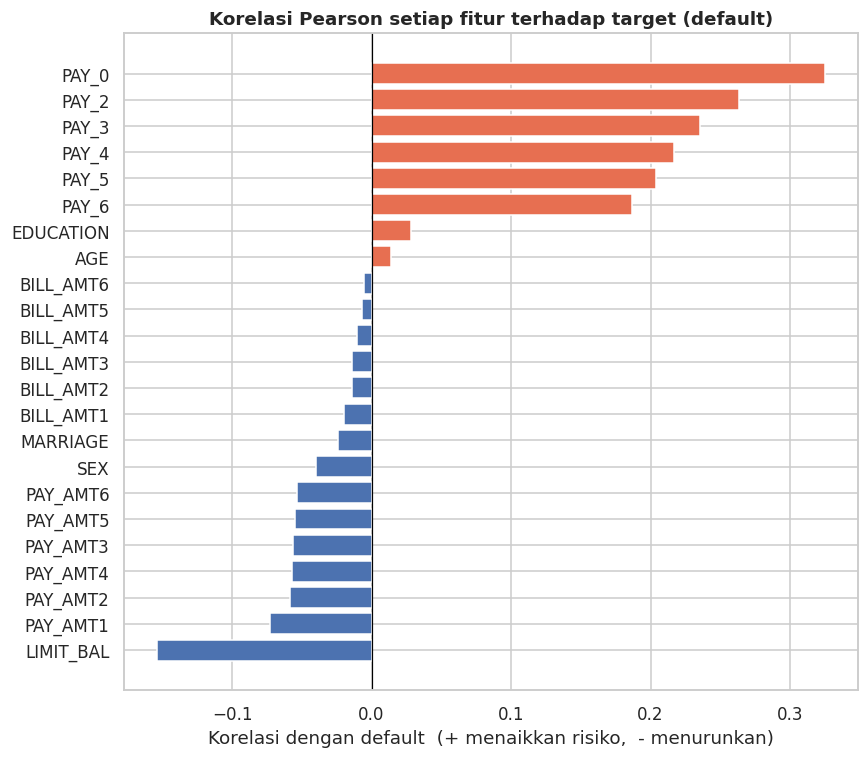

In [21]:
corr_t = df.drop(columns=["ID"]).corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(8, 7))
colors = [C_GAGAL if v > 0 else ACCENT for v in corr_t.values]
plt.barh(corr_t.index, corr_t.values, color=colors, edgecolor="white")
plt.axvline(0, color="black", lw=0.8)
plt.title("Korelasi Pearson setiap fitur terhadap target (default)")
plt.xlabel("Korelasi dengan default  (+ menaikkan risiko,  - menurunkan)")
plt.tight_layout(); plt.show()

**Insight:** Variabel **status pembayaran `PAY_*`** mendominasi korelasi positif terhadap default (`PAY_0` tertinggi ≈ 0,32) — menegaskan temuan 8.3. Sebaliknya `LIMIT_BAL` berkorelasi **negatif** (≈ −0,15): limit lebih besar → risiko lebih rendah. `BILL_AMT*` nyaris tak berkorelasi langsung dengan target → nilainya lebih pada **fitur turunan** (rasio/tren), bukan nilai mentah.

### 9.3 Pratinjau fitur turunan: rasio utilisasi kredit

Karena `BILL_AMT` mentah lemah berkorelasi tetapi `LIMIT_BAL` relevan, **rasio utilisasi** (`BILL_AMT1 / LIMIT_BAL`) sering jadi sinyal kuat. Plot ini menjadi *teaser* mengapa *feature extraction* berguna.

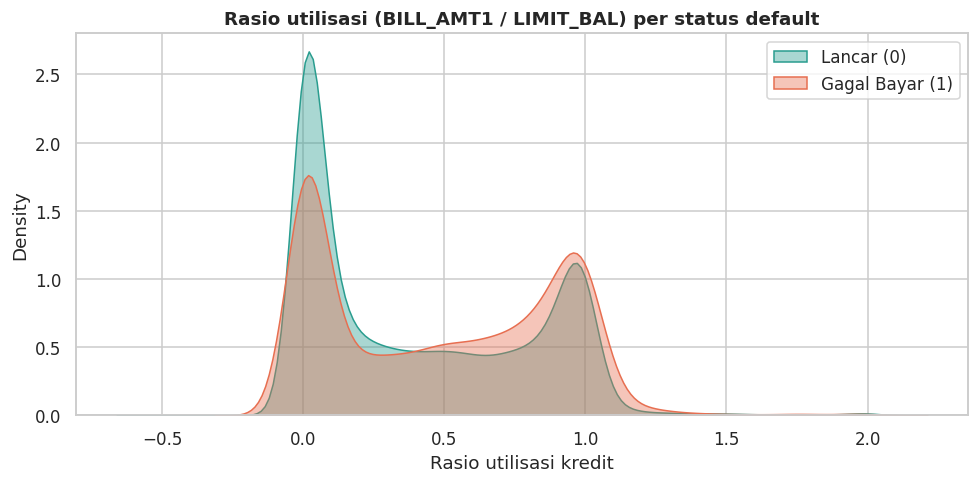

In [22]:
util = (df["BILL_AMT1"] / (df["LIMIT_BAL"] + 1)).clip(-0.5, 2)  # clip hanya untuk keterbacaan visual

plt.figure(figsize=(9, 4.5))
for t in [0, 1]:
    sns.kdeplot(util[df[TARGET] == t], fill=True, alpha=0.4,
                color=TARGET_PALETTE[t], label=TARGET_LABELS[t])
plt.title("Rasio utilisasi (BILL_AMT1 / LIMIT_BAL) per status default")
plt.xlabel("Rasio utilisasi kredit"); plt.legend()
plt.tight_layout(); plt.show()

**Insight:** Klien **gagal bayar** condong ke **utilisasi tinggi** (memakai porsi besar dari limit) — pola yang tidak terlihat dari `BILL_AMT` mentah. Ini membenarkan strategi membuat fitur turunan seperti rata-rata utilisasi, jumlah bulan telat, dan tren tagihan pada tahap preprocessing.

## 10. Ringkasan Temuan → Implikasi untuk Preprocessing

| # | Temuan EDA | Implikasi / Keputusan Preprocessing |
|---|---|---|
| 1 | `ID` hanya identifier; `PAY_0` lebih tepat dinamai `PAY_1` | Drop `ID`, samakan penamaan kolom |
| 2 | **35 baris duplikat** (tanpa `ID`) | Hapus duplikat agar model tak bias |
| 3 | `EDUCATION ∈ {0,5,6}` & `MARRIAGE = 0` di luar dokumentasi (porsi kecil) | Tandai sebagai `NaN` → **imputasi** (mis. KNN) |
| 4 | `PAY_* ∈ {-2, 0}` di luar dokumentasi tapi bermakna | **Pertahankan** (bukan error) |
| 5 | Kolom uang **sangat menceng kanan** & berekor panjang; ada nilai negatif wajar | **Outlier capping (IQR)** + **scaling** |
| 6 | `BILL_AMT` **multikolinear** (≈0,89); riwayat 6 bulan redundan | **Feature extraction** (utilisasi, tren, jumlah telat) + buang fitur sangat berkorelasi |
| 7 | Fitur kategorik berkode angka | **Encoding** (One-Hot untuk nominal, Label untuk biner) |
| 8 | Hubungan umur–risiko lemah & mungkin non-linear | Opsional: **binning** `AGE` |
| 9 | `PAY_*` prediktor terkuat; `LIMIT_BAL` & utilisasi relevan | Pastikan dipertahankan saat **feature selection** |
| 10 | Target **timpang** (~22% default) | Evaluasi pakai **AUC/recall/F1** + **imbalance handling** |

**Kesimpulan:** Dataset relatif bersih dari `NaN` eksplisit, tetapi tantangan utamanya adalah **kategori tak terdokumentasi**, **skewness kolom uang**, **multikolinearitas riwayat bulanan**, dan **ketidakseimbangan target**. Keempat hal inilah yang akan ditangani secara berurutan pada `Preprocessing_Modeling_EndToEnd_.ipynb`.

> Langkah berikutnya → buka **`Preprocessing_Modeling_EndToEnd_.ipynb`** dan jalankan pipeline pembersihan + modeling.